24BAD050-JOHIYA SRI S


Saving archive (3).zip to archive (3).zip
Dataset extracted successfully
/content/cats_dogs 0
/content/cats_dogs/test 0
/content/cats_dogs/test/dogs 70
/content/cats_dogs/test/cats 70
/content/cats_dogs/train 0
/content/cats_dogs/train/dogs 278
/content/cats_dogs/train/cats 279
Total images: 697
Cat images: 349
Dog images: 348
Found 487 images belonging to 2 classes.
Found 104 images belonging to 2 classes.
Found 106 images belonging to 2 classes.
Class indices: {'cat': 0, 'dog': 1}


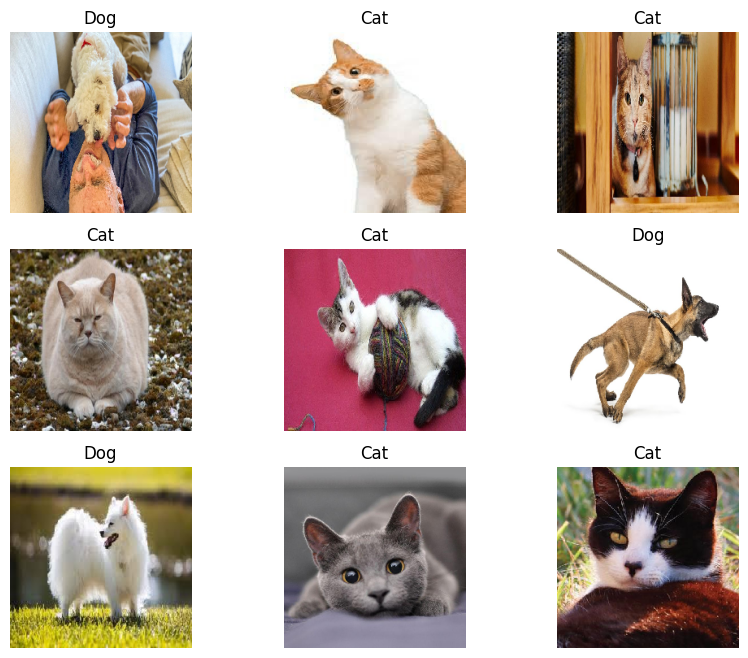

In [1]:
print("24BAD050-JOHIYA SRI S")
import os
import zipfile
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/cats_dogs')

print("Dataset extracted successfully")

for root, dirs, files_list in os.walk('/content/cats_dogs'):
    print(root, len(files_list))

base_path = '/content/cats_dogs'

image_files = []

for root, dirs, files_list in os.walk(base_path):
    for file in files_list:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_files.append(os.path.join(root, file))

print("Total images:", len(image_files))

cat_images = [x for x in image_files if 'cat' in os.path.basename(x).lower()]
dog_images = [x for x in image_files if 'dog' in os.path.basename(x).lower()]

print("Cat images:", len(cat_images))
print("Dog images:", len(dog_images))

random.seed(42)

random.shuffle(cat_images)
random.shuffle(dog_images)

dataset_dir = '/content/final_dataset'

for split in ['train', 'validation', 'test']:
    for category in ['cat', 'dog']:
        os.makedirs(os.path.join(dataset_dir, split, category), exist_ok=True)

def split_and_copy(images, category):
    total = len(images)

    train_end = int(0.70 * total)
    validation_end = int(0.85 * total)

    train_images = images[:train_end]
    validation_images = images[train_end:validation_end]
    test_images = images[validation_end:]

    for img in train_images:
        shutil.copy(img, os.path.join(dataset_dir, 'train', category))

    for img in validation_images:
        shutil.copy(img, os.path.join(dataset_dir, 'validation', category))

    for img in test_images:
        shutil.copy(img, os.path.join(dataset_dir, 'test', category))

split_and_copy(cat_images, 'cat')
split_and_copy(dog_images, 'dog')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_data = validation_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_data.class_indices)

images, labels = next(train_data)

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title('Dog' if np.argmax(labels[i]) == 1 else 'Cat')

plt.show()

In [2]:
print("24BAD050-JOHIYA SRI S")
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("Transfer learning model created successfully")
print("Pre-trained ResNet50 layers are frozen")
print("Final layer contains 2 classes: Cat and Dog")

24BAD050-JOHIYA SRI S
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Transfer learning model created successfully
Pre-trained ResNet50 layers are frozen
Final layer contains 2 classes: Cat and Dog


24BAD050-JOHIYA SRI S
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 94s 6s/step - accuracy: 0.4497 - loss: 0.7270 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 0.5154 - loss: 0.6982 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.5544 - loss: 0.6854 - val_accuracy: 0.5865 - val_loss: 0.6884
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step - accuracy: 0.5791 - loss: 0.6828 - val_accuracy: 0.5865 - val_loss: 0.6845
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 79s 5s/step - accuracy: 0.5729 - loss: 0.6802 - val_accuracy: 0.5769 - val_loss: 0.6827
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6226 - loss: 0.6755

========== PERFORMANCE RESULTS ==========
Training Accuracy   : 57.29 %
Validation Accuracy : 57.69 %
Training Loss       : 0.6802
Validation Loss     : 0.6827
Test Accuracy       : 62.26 %


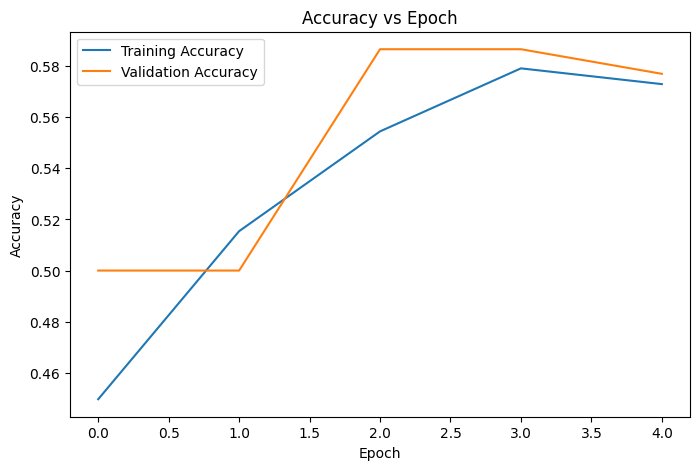

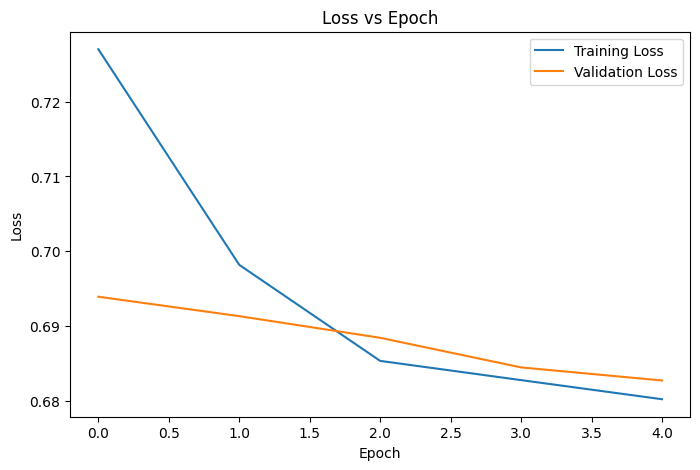

Epoch 1/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 123s 7s/step - accuracy: 0.5873 - loss: 0.6688 - val_accuracy: 0.5385 - val_loss: 0.6826
Epoch 2/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 102s 6s/step - accuracy: 0.7844 - loss: 0.5549 - val_accuracy: 0.5096 - val_loss: 0.6837
Epoch 3/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 98s 6s/step - accuracy: 0.8460 - loss: 0.4851 - val_accuracy: 0.4712 - val_loss: 0.6852
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5377 - loss: 0.6742

========== FINE-TUNING RESULTS ==========
Fine-Tuned Test Accuracy: 53.77 %


In [3]:
print("24BAD050-JOHIYA SRI S")
import matplotlib.pyplot as plt
EPOCHS = 5
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS
)

test_loss, test_accuracy = model.evaluate(test_data)

training_accuracy = history.history['accuracy'][-1]
validation_accuracy = history.history['val_accuracy'][-1]
training_loss = history.history['loss'][-1]
validation_loss = history.history['val_loss'][-1]

print("\n========== PERFORMANCE RESULTS ==========")
print("Training Accuracy   :", round(training_accuracy * 100, 2), "%")
print("Validation Accuracy :", round(validation_accuracy * 100, 2), "%")
print("Training Loss       :", round(training_loss, 4))
print("Validation Loss     :", round(validation_loss, 4))
print("Test Accuracy       :", round(test_accuracy * 100, 2), "%")

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=3
)

fine_test_loss, fine_test_accuracy = model.evaluate(test_data)

print("\n========== FINE-TUNING RESULTS ==========")
print("Fine-Tuned Test Accuracy:", round(fine_test_accuracy * 100, 2), "%")

24BAD050-JOHIYA SRI S


config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]


Actual: Cat
Hugging Face Prediction : Angora, Angora rabbit
Hugging Face Confidence : 31.19 %
Transfer Learning Prediction : dog
Transfer Learning Confidence : 50.07 %


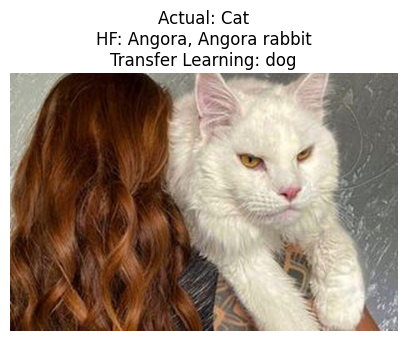


Actual: Dog
Hugging Face Prediction : beagle
Hugging Face Confidence : 51.7 %
Transfer Learning Prediction : dog
Transfer Learning Confidence : 53.86 %


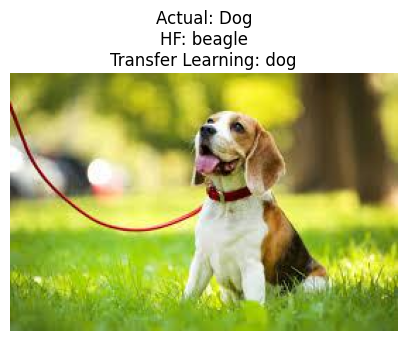

In [4]:
print("24BAD050-JOHIYA SRI S")
!pip install -q transformers

from transformers import pipeline
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

hf_model = pipeline(
    'image-classification',
    model='microsoft/resnet-50'
)

cat_folder = os.path.join(
    dataset_dir,
    'test',
    'cat'
)

dog_folder = os.path.join(
    dataset_dir,
    'test',
    'dog'
)

cat_image = os.path.join(
    cat_folder,
    os.listdir(cat_folder)[0]
)

dog_image = os.path.join(
    dog_folder,
    os.listdir(dog_folder)[0]
)

sample_images = [
    (cat_image, 'Actual: Cat'),
    (dog_image, 'Actual: Dog')
]

for image_path, actual_label in sample_images:

    image = Image.open(image_path).convert('RGB')

    hf_results = hf_model(image)

    hf_prediction = hf_results[0]['label']
    hf_confidence = hf_results[0]['score']

    image_array = np.array(image.resize((224, 224)))
    image_array = image_array / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    transfer_result = model.predict(image_array, verbose=0)

    class_names = list(train_data.class_indices.keys())

    transfer_index = np.argmax(transfer_result)
    transfer_prediction = class_names[transfer_index]
    transfer_confidence = transfer_result[0][transfer_index]

    print("\n===================================")
    print(actual_label)
    print("Hugging Face Prediction :", hf_prediction)
    print("Hugging Face Confidence :", round(hf_confidence * 100, 2), "%")
    print("Transfer Learning Prediction :", transfer_prediction)
    print("Transfer Learning Confidence :", round(transfer_confidence * 100, 2), "%")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(
        f"{actual_label}\n"
        f"HF: {hf_prediction}\n"
        f"Transfer Learning: {transfer_prediction}"
    )
    plt.show()